In [1]:
# Install torch if required
# !pip install torch transformers

In [2]:
# Install langdetect if required
# !pip install langdetect

In [21]:
# Install yfinance if required
# !pip install yfinance

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334



  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------------------------- - 1.6/1.6 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 7.8 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15618 sha256=d35d1a69fec8085e2db45e951e4716c6c9fc45ae2854a510d17596338bc48748
  Stored in directory: c:\users\alext\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfi

In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import torch
import requests
import time
import os
import glob
import torch.nn.functional as F
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datetime import datetime, timedelta, date
from dotenv import load_dotenv
from langdetect import detect, DetectorFactory
from statistics import mode
from datetime import date

In [2]:
# Set pandas to UK format
pd.options.display.date_dayfirst = True

In [3]:
os.getcwd()

'C:\\Users\\alext\\VP Analytics Project'

In [2]:
# Import csv with all companies' reporting dates
company_dates = pd.read_csv("Earnings Calls Dates.csv", dayfirst=True)

company_dates.head()

,Company,Ticker,release_date
0,Nvidia,NVDA,24/02/2021
1,Nvidia,NVDA,26/05/2021
2,Nvidia,NVDA,18/08/2021
3,Nvidia,NVDA,17/11/2021
4,Nvidia,NVDA,16/02/2022


In [3]:
pd.to_datetime("01/02/2024")


Timestamp('2024-01-02 00:00:00')

In [4]:
# Define event windows function
def get_event_windows_for_companies(df, pre_event_days=7):
    """
    Takes a dataframe with columns: Company, Ticker, release_date
    Returns a dataframe with event windows for each release date.
    """
    records = []

    for _, row in df.iterrows():
        company = row["Company"]
        ticker = row["Ticker"]
        release_date = pd.to_datetime(row["release_date"], dayfirst=True)

        start = release_date - timedelta(days=pre_event_days)
        end = release_date - timedelta(days=1)

        records.append({
            "company": company,
            "ticker": ticker,
            "release_date": release_date.date(),
            "window_start": start.date(),
            "window_end": end.date()
        })

    return pd.DataFrame(records)

In [5]:
# Run function to populate event_windows dataframe
event_windows = get_event_windows_for_companies(company_dates)
event_windows

,company,ticker,release_date,window_start,window_end
0,Nvidia,NVDA,2021-02-24,2021-02-17,2021-02-23
1,Nvidia,NVDA,2021-05-26,2021-05-19,2021-05-25
2,Nvidia,NVDA,2021-08-18,2021-08-11,2021-08-17
3,Nvidia,NVDA,2021-11-17,2021-11-10,2021-11-16
4,Nvidia,NVDA,2022-02-16,2022-02-09,2022-02-15
...,...,...,...,...,...
59,Apple,AAPL,2023-11-02,2023-10-26,2023-11-01
60,Apple,AAPL,2024-02-01,2024-01-25,2024-01-31
61,Apple,AAPL,2024-05-02,2024-04-25,2024-05-01
62,Apple,AAPL,2024-08-01,2024-07-25,2024-07-31


In [6]:
# Save to CSV
event_windows.to_csv("Event_Windows.csv",index=False)

In [7]:
# Load .env for mediastack API key
load_dotenv()

API_KEY = os.getenv("MEDIASTACK_API_KEY")

if API_KEY is None:
    print("No API key found. Using cached dataset instead.")
else:
    print("API key loaded successfully.")


API key loaded successfully.


In [8]:
# Define mediastack query
def ms_news_query(company, date_from, date_to):
    """
    Take a company name, start and end date as parameters
    and put these into the mediastack query format. Uses personal
    .env file with API key and returns a message if someone
    else runs the query with no API key of their own.
    """
    if API_KEY is None:
        print("No API key found. Cannot fetch live data.")
        return None

    all_data = []
    offset = 0
    limit = 100

    while True:
        url = "http://api.mediastack.com/v1/news"
        params = {
            "access_key": API_KEY,
            "keywords": company.lower(),
            "date": f"{date_from},{date_to}",
            "limit": limit,
            "offset": offset,
            "sort": "published_desc",
            "languages": "en"
        }

        response = requests.get(url, params=params)
        response.raise_for_status()
        result = response.json()

        batch = result.get("data", [])
        all_data.extend(batch)

        # Breaks the while function on last page.
        if len(batch) < limit:
            break

        offset += limit

    return all_data


In [9]:
# For loop to return all CSVs for all 448 days
""" A loop that runs through every company and
earnings call event window combination as input
parameters for the mediastack query function. 
This is included to clarity but to avoid repeatedly
calling Mediastack it will be commented with a #
once all CSVs are obtained"""

# for _, row in event_windows.iterrows():
#    company = row["company"]
#    ticker = row["ticker"]
#    start = pd.to_datetime(row["window_start"])
#    end = pd.to_datetime(row["window_end"])

#    current_day = start

#    while current_day <= end:
#        date_from = current_day.strftime("%Y-%m-%d")
#        date_to = current_day.strftime("%Y-%m-%d")

#       print(f"Fetching {company} ({ticker}) for {date_from}")

#        data = ms_news_query(company, date_from, date_to)

#        df = pd.DataFrame(data)

#       # Save each day's results
#        filename = f"{ticker}_{date_from}.csv"
#        df.to_csv(filename, index=False)

#       current_day += timedelta(days=1)

' A loop that runs through every company and\nearnings call event window combination as input\nparameters for the mediastack query function. \nThis is included to clarity but to avoid repeatedly\ncalling Mediastack it will be commented with a #\nonce all CSVs are obtained'

#### Observation
A visual observation of the CSVs showed that, even with using the "en" parameter for the mediastack query, a small number of articles not in English were returned. They were incorrectly classified as "en" in the mediastack database. As an additional data cleaning process we will langdetect package to scan the downloaded data and removed any non-english items still returned by our query.

In [10]:
# Set langdetect seed for consistent results
DetectorFactory.seed = 0

# Define langdetect function
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"


In [11]:
# Create a for loop to run langdetect on every CSV
"""Define a mediastack CSV folder with no other CSVs
and run the langdetect function for each CSV. Takes the data
as a pandas dataframe, removes non-english rows and resaves 
to the same CSV filename."""

# folder = "C:\\Users\\alext\\VP Analytics Project\\MS CSVs"  # Folder with only mediastack CSVs

# for file in glob.glob(f"{folder}/*.csv"):
#    try:
#        df = pd.read_csv(file)
#    except pd.errors.EmptyDataError:
#        print(f"Skipping empty CSV: {file}")
#        continue

#    df["language"] = df["description"].apply(detect_language)

#    # Keep only English
#    df = df[df["language"] == "en"]

#    df.to_csv(file, index=False)

'Define a mediastack CSV folder with no other CSVs\nand run the langdetect function for each CSV. Takes the data\nas a pandas dataframe, removes non-english rows and resaves \nto the same CSV filename.'

#### Coding adjustment
Initial running of the for loop generated an error when reaching a date with an empty CSV i.e. no returned news articles on that day. Added a try clause to keep the loop running in this case.

#### Observation
Visual observation shows that there are duplicate articles therefore we shall remove duplicate articles using the title column.


In [12]:
# Create a for loop to remove duplicate titles
""" We will convert title to lowercase and remove
duplicate rows. Empty titles will be treated as
duplicates and as such removed. This will use the same code
structure and try condition as the langdetect loop"""

# for file in glob.glob(f"{folder}/*.csv"):

#    try:
#        df = pd.read_csv(file)
#    except pd.errors.EmptyDataError:
#        print(f"Skipping empty or malformed CSV: {file}")
#        continue

#    # Remove duplicates
#    df["title_clean"] = df["title"].fillna("").str.lower()
#    before = len(df)
#    df = df.drop_duplicates(subset="title_clean")
#    after = len(df)

#    print(f"{file}: removed {before - after} duplicates")

#    df = df.drop(columns=["title_clean"])
#    df.to_csv(file, index=False)

' We will convert title to lowercase and remove\nduplicate rows. Empty titles will be treated as\nduplicates and as such removed. This will use the same code\nstructure and try condition as the langdetect loop'

### Merging individual CSVs into 7 day event windows

In [13]:
# Define source and target folders
source_folder = r"C:\Users\alext\VP Analytics Project\MS CSVs"
output_base = r"C:\Users\alext\VP Analytics Project\Event Window Datasets"

# Define our window data merging function
def load_window_data(ticker, start, end):
    """Load and merge the 7 daily CSVs for a given event window."""
    dates = pd.date_range(start, end).strftime("%Y-%m-%d").tolist()
    dfs = []

    for d in dates:
        filename = f"{ticker}_{d}.csv"
        filepath = os.path.join(source_folder, filename)

        if not os.path.exists(filepath): # Safety clause
            print(f"Missing file: {filepath}")
            continue

        try:
            df = pd.read_csv(filepath) # Safety clause
        except pd.errors.EmptyDataError:
            print(f"Skipping empty or malformed CSV: {filepath}")
            continue

        df["date"] = d
        dfs.append(df)

    if dfs:
        return pd.concat(dfs, ignore_index=True)
    else:
        return pd.DataFrame()

In [14]:
# Run the window merging function for each company event window
""" This will take each company and 7 day event window and run
the load_window_data function. This will condsense 448 individual
daily CSVs into 64 CSVs. One for each company release date combination.
It will include a print out for each saved CSV as well as a check to
see if any merged CSV is empty."""
# for idx, row in event_windows.iterrows():
#    ticker = row["ticker"]
#    start = row["window_start"]
#    end = row["window_end"]

    # Load merged data for this window
#    merged_df = load_window_data(ticker, start, end)

#    if merged_df.empty:
#        print(f"No data for window {idx} ({ticker} {start} to {end})")
#        continue

    # Build output filename
#    output_filename = f"{ticker}-{start}-to-{end}.csv"

    # Build output folder path
#    ticker_folder = os.path.join(output_base, ticker)
#    os.makedirs(ticker_folder, exist_ok=True)

    # Save merged CSV
#    output_path = os.path.join(ticker_folder, output_filename)
#    merged_df.to_csv(output_path, index=False)

#    print(f"Saved: {output_path}")

' This will take each company and 7 day event window and run\nthe load_window_data function. This will condsense 448 individual\ndaily CSVs into 64 CSVs. One for each company release date combination.\nIt will include a print out for each saved CSV as well as a check to\nsee if any merged CSV is empty.'

#### Observation
15 Merged CSVs successfully created. No CSV created for the NVDA release on 24-02-2021.

### Using FinBERT for financial sentiment analysis

In [9]:
# load FinBERT model
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
# Define the finbert sentiment function
"""
If the input is missing or not a string, return a default neutral
sentiment. Otherwise, tokenize the text and convert it into PyTorch
tensors, run it through the FinBERT model. Then apply softmax to obtain
probabilities, and return both the probabilities and the
predicted sentiment label.
"""
def finbert_sentiment(text):
    if not isinstance(text, str) or len(text.strip()) == 0: # Check input data
        return {"label": "neutral", "positive": 0, "neutral": 1, "negative": 0}

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)[0] # Convert logits to probabilities
    labels = ["positive", "neutral", "negative"]
    scores = {labels[i]: float(probs[i]) for i in range(3)}
    scores["label"] = labels[probs.argmax().item()]
    return scores


#### More detailed comments on code
From redearch it was determined to use torch.nograd() line putting us in 'inference' mode. This means we are not training or updating the model and so turns off gradient tracking. This speeds up computation and is therefore more efficient for our project.

F.softmax(...) converts FinBERT’s raw logits into normalized probabilities for the positive, neutral, and negative classes. Softmax ensures the values sum to 1, giving more easily interpretable class probabilities rather than unbounded model scores.


#### Applying FinBERT to all cleaned CSVs

Running the model can take a few minutes for a single CSV (from a single file test). Therefore I will write a single foor loop that also saves the sentiment scores back to the CSV. This means the sentiment analysis is saved and the model is not required to be loaded each time this script is ran. It will be ran once, output stored in the Jupyter file and then the function and for loop will be commented out with # so it doesn't try and run each time the kernel/machine is restarted.

In [16]:
# Define the folder containing the four company subfolders
"""As there are many CSVs they have been split into individual
company subfolders. However, for the simplicity of the for loop
the will effectively merge these to run once"""
# merged_folder = r"C:\Users\alext\VP Analytics Project\Event Window Datasets"

# List of company folders
# companies = ["AAPL", "MSFT", "NVDA", "GOOGL"]

# For loop to analyse each event window CSV
"""Processes each event‑window CSV by applying the FinBERT sentiment model
to all article descriptions and saving the results back to the
same file. The loop iterates through each company's subfolder (the list
is adjustable for future expansion). Because sentiment scoring is
computationally intensive, progress print statements are included to
help monitor long runs and identify any issues during execution.
"""
# for company in companies:
#    company_folder = os.path.join(merged_folder, company)
#    print(f"\nProcessing company: {company}")

    # Loop through all CSVs in that company's folder
#    for file in glob.glob(os.path.join(company_folder, "*.csv")):
#        print(f"  → Running FinBERT on: {os.path.basename(file)}")

#        df = pd.read_csv(file)

        # Apply FinBERT to each description
#        sentiments = df["description"].apply(finbert_sentiment)

#        df["sentiment_label"] = sentiments.apply(lambda x: x["label"])
#        df["positive"] = sentiments.apply(lambda x: x["positive"])
#        df["neutral"] = sentiments.apply(lambda x: x["neutral"])
#        df["negative"] = sentiments.apply(lambda x: x["negative"])

        # Save enriched CSV back to disk
#        df.to_csv(file, index=False)

#    print(f"Finished {company}")


"Processes each event‑window CSV by applying the FinBERT sentiment model\nto all article descriptions and saving the results back to the\nsame file. The loop iterates through each company's subfolder (the list\nis adjustable for future expansion). Because sentiment scoring is\ncomputationally intensive, progress print statements are included to\nhelp monitor long runs and identify any issues during execution.\n"

#### Generating expected market returns
To compare abnormal returns you need to compare company actual returns to expected market returns. To do this there is a ticker for the S&P 500 which gives price data for the market as a whole. Using the same dates and return calculations we can therefore determine the market expected return. To do this we will generate a CSV one time (following execution the code will be commented out) with S&P 500 prices for our analysis period of 2021-2024 to create a CSV. The start and end dates can be ammended in future uses.

In [24]:
# Generate estimated market prices for S&P500 for set date range
"""One time use, can amend start and end days for future use and
run again for a different analysis period"""
# sp500 = yf.Ticker("^GSPC")
# sp500_21_24 = sp500.history(start="2021-01-01", end="2024-12-31")

# sp500_21_24.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,3764.610107,3769.989990,3662.709961,3700.649902,5015000000,0.0,0.0
2021-01-05 00:00:00-05:00,3698.020020,3737.830078,3695.070068,3726.860107,4591020000,0.0,0.0
2021-01-06 00:00:00-05:00,3712.199951,3783.040039,3705.340088,3748.139893,6064110000,0.0,0.0
2021-01-07 00:00:00-05:00,3764.709961,3811.550049,3764.709961,3803.790039,5099160000,0.0,0.0
2021-01-08 00:00:00-05:00,3815.050049,3826.689941,3783.600098,3824.679932,4773040000,0.0,0.0


In [26]:
# Save to CSV
#sp500_21_24.to_csv("SP500_21_24_Yahoo.csv")

#### Generating selected company price data

In [37]:
# Generate estimated market prices for NVDA for set date range
"""One time use, can amend start and end days for future use and
run again for a different analysis period"""
nvda = yf.Ticker("NVDA")
nvda_21_24 = nvda.history(start="2021-01-01", end="2024-12-31")

nvda_21_24.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,13.067502,13.614215,12.926149,13.076726,560640000,0.0,0.0
2021-01-05 00:00:00-05:00,13.063014,13.405800,13.050300,13.367159,322760000,0.0,0.0
2021-01-06 00:00:00-05:00,13.185421,13.207858,12.550707,12.579126,580424000,0.0,0.0
2021-01-07 00:00:00-05:00,12.931135,13.340235,12.850363,13.306580,461480000,0.0,0.0
2021-01-08 00:00:00-05:00,13.325028,13.383364,13.005427,13.239518,292528000,0.0,0.0


In [38]:
# Save to CSV
#nvda_21_24.to_csv("nvda_21_24_Yahoo.csv")

In [39]:
# Generate estimated market prices for AAPL for set date range
"""One time use, can amend start and end days for future use and
run again for a different analysis period"""
#aapl = yf.Ticker("AAPL")
#aapl_21_24 = aapl.history(start="2021-01-01", end="2024-12-31")

#aapl_21_24.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,129.853838,129.941364,123.279451,125.856689,143301900,0.0,0.0
2021-01-05 00:00:00-05:00,125.350958,128.122709,124.903582,127.412743,97664900,0.0,0.0
2021-01-06 00:00:00-05:00,124.213106,127.451673,122.909895,123.123856,155088000,0.0,0.0
2021-01-07 00:00:00-05:00,124.835528,128.015745,124.349256,127.325233,109578200,0.0,0.0
2021-01-08 00:00:00-05:00,128.793750,128.988271,126.654160,128.424194,105158200,0.0,0.0


In [40]:
# Save to CSV
#aapl_21_24.to_csv("aapl_21_24_Yahoo.csv")

In [41]:
# Generate estimated market prices for GOOGL for set date range
"""One time use, can amend start and end days for future use and
run again for a different analysis period"""
#googl = yf.Ticker("GOOGL")
#googl_21_24 = googl.history(start="2021-01-01", end="2024-12-31")

#googl_21_24.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,87.340084,87.463646,84.716906,85.659286,37324000,0.0,0.0
2021-01-05 00:00:00-05:00,85.607675,86.686522,85.201246,86.350067,20360000,0.0,0.0
2021-01-06 00:00:00-05:00,84.375486,86.544598,84.169045,85.498001,46588000,0.0,0.0
2021-01-07 00:00:00-05:00,85.690547,88.224403,85.690547,88.051712,41936000,0.0,0.0
2021-01-08 00:00:00-05:00,88.191657,89.293333,87.400629,89.217407,35484000,0.0,0.0


In [42]:
# Save to CSV
#googl_21_24.to_csv("googl_21_24_Yahoo.csv")

In [43]:
# Generate estimated market prices for MSFT for set date range
"""One time use, can amend start and end days for future use and
run again for a different analysis period"""
#msft = yf.Ticker("MSFT")
#msft_21_24 = msft.history(start="2021-01-01", end="2024-12-31")

#msft_21_24.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00-05:00,213.526386,213.977371,206.118738,208.882217,37130100,0.0,0.0
2021-01-05 00:00:00-05:00,208.469605,209.678634,206.972725,209.083710,23823000,0.0,0.0
2021-01-06 00:00:00-05:00,203.585497,207.730715,203.364807,203.662262,35930700,0.0,0.0
2021-01-07 00:00:00-05:00,205.379932,210.465497,205.063297,209.457977,27694500,0.0,0.0
2021-01-08 00:00:00-05:00,209.832146,211.655280,208.248911,210.734116,22956200,0.0,0.0


In [44]:
# Save to CSV
#msft_21_24.to_csv("msft_21_24_Yahoo.csv")

### Creating scalable functions for multiple event windows

Load the stock price tables; S&P 500 and selcted companies

In [29]:
# Load S&P 500 CSV and convert date column
sp500 = pd.read_csv(r"C:\Users\alext\VP Analytics Project\Stock Price Data\SP500_21_24_Yahoo.csv")

sp500["Date"] = pd.to_datetime(sp500["Date"], utc=True, errors="coerce")
sp500["Date"] = sp500["Date"].dt.date

# View output
sp500.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-01-04,3764.610107,3769.989990,3662.709961,3700.649902,5015000000,0.0,0.0
1,2021-01-05,3698.020020,3737.830078,3695.070068,3726.860107,4591020000,0.0,0.0
2,2021-01-06,3712.199951,3783.040039,3705.340088,3748.139893,6064110000,0.0,0.0
3,2021-01-07,3764.709961,3811.550049,3764.709961,3803.790039,5099160000,0.0,0.0
4,2021-01-08,3815.050049,3826.689941,3783.600098,3824.679932,4773040000,0.0,0.0


In [47]:
# Load NVDA CSV and convert date column
nvda_price = pd.read_csv(r"C:\Users\alext\VP Analytics Project\Stock Price Data\nvda_21_24_Yahoo.csv")

nvda_price["Date"] = pd.to_datetime(nvda_price["Date"], utc=True, errors="coerce")
nvda_price["Date"] = nvda_price["Date"].dt.date

# View output
nvda_price.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-01-04,13.067502,13.614215,12.926149,13.076726,560640000,0.0,0.0
1,2021-01-05,13.063014,13.405800,13.050300,13.367159,322760000,0.0,0.0
2,2021-01-06,13.185421,13.207858,12.550707,12.579126,580424000,0.0,0.0
3,2021-01-07,12.931135,13.340235,12.850363,13.306580,461480000,0.0,0.0
4,2021-01-08,13.325028,13.383364,13.005427,13.239518,292528000,0.0,0.0


In [48]:
# Load AAPL CSV and convert date column
aapl_price = pd.read_csv(r"C:\Users\alext\VP Analytics Project\Stock Price Data\aapl_21_24_Yahoo.csv")

aapl_price["Date"] = pd.to_datetime(aapl_price["Date"], utc=True, errors="coerce")
aapl_price["Date"] = aapl_price["Date"].dt.date

# View output
aapl_price.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-01-04,129.853838,129.941364,123.279451,125.856689,143301900,0.0,0.0
1,2021-01-05,125.350958,128.122709,124.903582,127.412743,97664900,0.0,0.0
2,2021-01-06,124.213106,127.451673,122.909895,123.123856,155088000,0.0,0.0
3,2021-01-07,124.835528,128.015745,124.349256,127.325233,109578200,0.0,0.0
4,2021-01-08,128.793750,128.988271,126.654160,128.424194,105158200,0.0,0.0


In [49]:
# Load GOOGL CSV and convert date column
googl_price = pd.read_csv(r"C:\Users\alext\VP Analytics Project\Stock Price Data\googl_21_24_Yahoo.csv")

googl_price["Date"] = pd.to_datetime(googl_price["Date"], utc=True, errors="coerce")
googl_price["Date"] = googl_price["Date"].dt.date

# View output
googl_price.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-01-04,87.340084,87.463646,84.716906,85.659286,37324000,0.0,0.0
1,2021-01-05,85.607675,86.686522,85.201246,86.350067,20360000,0.0,0.0
2,2021-01-06,84.375486,86.544598,84.169045,85.498001,46588000,0.0,0.0
3,2021-01-07,85.690547,88.224403,85.690547,88.051712,41936000,0.0,0.0
4,2021-01-08,88.191657,89.293333,87.400629,89.217407,35484000,0.0,0.0


In [50]:
# Load MSFT CSV and convert date column
msft_price = pd.read_csv(r"C:\Users\alext\VP Analytics Project\Stock Price Data\msft_21_24_Yahoo.csv")

msft_price["Date"] = pd.to_datetime(msft_price["Date"], utc=True, errors="coerce")
msft_price["Date"] = msft_price["Date"].dt.date

# View output
msft_price.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-01-04,213.526386,213.977371,206.118738,208.882217,37130100,0.0,0.0
1,2021-01-05,208.469605,209.678634,206.972725,209.083710,23823000,0.0,0.0
2,2021-01-06,203.585497,207.730715,203.364807,203.662262,35930700,0.0,0.0
3,2021-01-07,205.379932,210.465497,205.063297,209.457977,27694500,0.0,0.0
4,2021-01-08,209.832146,211.655280,208.248911,210.734116,22956200,0.0,0.0


In [73]:
# Create a dictionary mapping tickers to price tables
price_tables = {
    "AAPL": aapl_price,
    "MSFT": msft_price,
    "GOOGL": googl_price,
    "NVDA": nvda_price
}

# Create a dictionary mapping tickers to sentiment subfolders
sentiment_dirs = {
    "AAPL": r"C:\Users\alext\VP Analytics Project\Event Window Datasets\AAPL",
    "MSFT": r"C:\Users\alext\VP Analytics Project\Event Window Datasets\MSFT",
    "GOOGL": r"C:\Users\alext\VP Analytics Project\Event Window Datasets\GOOGL",
    "NVDA": r"C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA"
}

In [97]:
# Define a function to get a returns for a company for a release date
def get_company_return(df, release_date):
    before = release_date - timedelta(days=1)
    after  = release_date + timedelta(days=1)
    P_before = df.loc[df["Date"] == before, "Close"].iloc[0]
    P_after  = df.loc[df["Date"] == after, "Close"].iloc[0]
    return (P_after - P_before) / P_before


In [98]:
# Define a function to get market returns for a release date
"""sp500 dataframe will be a global variable and
so no need to specify a dataframe as a parameter"""
def get_market_return(release_date):
    before = release_date - timedelta(days=1)
    after  = release_date + timedelta(days=1)
    P_before = sp500.loc[sp500["Date"] == before, "Close"].iloc[0]
    P_after  = sp500.loc[sp500["Date"] == after, "Close"].iloc[0]
    return (P_after - P_before) / P_before

In [99]:
# Define a function to load processed mediastack CSVs
"""This takes CSVs that have already had FinBERT sentiment
probabilities and labels applied and calculates mean and
modal sentiment"""
def load_sentiment_window(csv_path):
    df = pd.read_csv(csv_path)
    df["polarity"] = df["positive"] - df["negative"]
    mean_polarity = df["polarity"].mean()
    mode_label = df["sentiment_label"].mode()[0]
    return mean_polarity, mode_label

In [100]:
# Define a function that will combine the different data
def process_event_row(row, sentiment_dirs, price_tables):
    ticker = row["ticker"]
    earnings_date = row["release_date"]
    window_start = row["window_start"]
    window_end = row["window_end"]

    # Build sentiment file path
    sentiment_filename = f"{ticker}-{window_start}-to-{window_end}.csv"
    sentiment_path = f"{sentiment_dirs[ticker]}/{sentiment_filename}"
    print("Looking for:", sentiment_path)

    # Load sentiment (skip if missing)
    try:
        mean_pol, mode_label = load_sentiment_window(sentiment_path)
    except FileNotFoundError:
        return None

    # Company return
    company_return = get_company_return(price_tables[ticker], earnings_date)

    # Market return (now uses global sp500)
    market_return = get_market_return(earnings_date)

    # Abnormal return
    abnormal_return = company_return - market_return

    return {
        "ticker": ticker,
        "earnings_date": earnings_date,
        "window_start": window_start,
        "window_end": window_end,
        "mean_polarity": mean_pol,
        "mode_label": mode_label,
        "company_return": company_return,
        "market_return": market_return,
        "abnormal_return": abnormal_return
    }

In [101]:
def build_event_study(event_windows, sentiment_dirs, price_tables):
    results = []

    for _, row in event_windows.iterrows():
        result = process_event_row(row, sentiment_dirs, price_tables)
        if result is not None:
            results.append(result)

    return pd.DataFrame(results)


In [106]:
# Run the functions to build the combplete data table
event_window_sentiment = build_event_study(
    event_windows,
    sentiment_dirs=sentiment_dirs,
    price_tables=price_tables
)

# View output
event_window_sentiment

Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2021-02-17-to-2021-02-23.csv
Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2021-05-19-to-2021-05-25.csv
Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2021-08-11-to-2021-08-17.csv
Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2021-11-10-to-2021-11-16.csv
Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2022-02-09-to-2022-02-15.csv
Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2022-05-18-to-2022-05-24.csv
Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2022-08-17-to-2022-08-23.csv
Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2022-11-09-to-2022-11-15.csv
Looking for: C:\Users\alext\VP Analytics Project\Event Window Datasets\NVDA/NVDA-2023-02-15-to-2023-02-21.csv
Looking fo

,ticker,earnings_date,window_start,window_end,mean_polarity,mode_label,company_return,market_return,abnormal_return
0,NVDA,2021-05-26,2021-05-19,2021-05-25,-0.269855,negative,-0.010209,0.003044,-0.013253
1,NVDA,2021-08-18,2021-08-11,2021-08-17,-0.496823,negative,0.017474,-0.009505,0.026979
2,NVDA,2021-11-17,2021-11-10,2021-11-16,-0.418621,negative,0.048737,0.000774,0.047963
3,NVDA,2022-02-16,2022-02-09,2022-02-15,-0.381139,negative,-0.075033,-0.020311,-0.054722
4,NVDA,2022-05-25,2022-05-18,2022-05-24,-0.358983,negative,0.105051,0.029522,0.075529
...,...,...,...,...,...,...,...,...,...
58,AAPL,2023-11-02,2023-10-26,2023-11-01,-0.417105,negative,0.015405,0.028429,-0.013025
59,AAPL,2024-02-01,2024-01-25,2024-01-31,-0.360437,negative,0.007863,0.023312,-0.015448
60,AAPL,2024-05-02,2024-04-25,2024-05-01,-0.470528,negative,0.083166,0.021800,0.061366
61,AAPL,2024-08-01,2024-07-25,2024-07-31,-0.273332,negative,-0.009996,-0.031824,0.021827


#### Data verfiication on created table

In [107]:
# Table shape
event_window_sentiment.shape

(63, 9)

In [108]:
# Check for null values
event_window_sentiment.isna().sum()

ticker             0
earnings_date      0
window_start       0
window_end         0
mean_polarity      0
mode_label         0
company_return     0
market_return      0
abnormal_return    0
dtype: int64

#### Correlation analysis

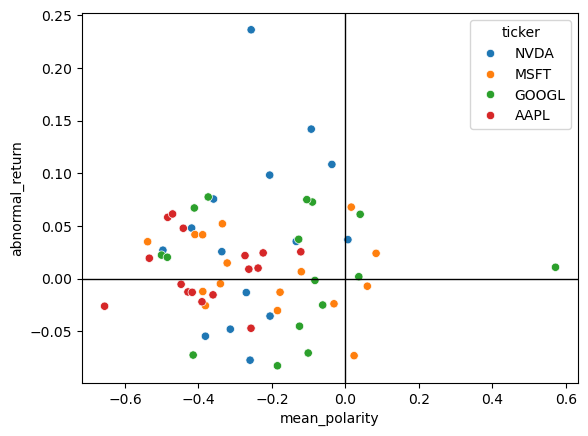

In [110]:
# Create a scatter plot comparing mean polarity and abnormal return
sns.scatterplot(
    data=event_window_sentiment,
    x="mean_polarity",
    y="abnormal_return",
    hue="ticker"
)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.show()

In [120]:
# Define OLS model function
""" This will create an OLS model output for
each unique ticket in the specified dataframe. In
this case the dataframe specified should be
even_window_sentiment"""
def company_ols(df):
    tickers = df["ticker"].unique()
    results = {}

    for t in tickers:
        subset = df[df["ticker"] == t]

        X = subset["mean_polarity"]
        y = subset["abnormal_return"]

        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()

        results[t] = model

    return results

In [122]:
# Build comparison table for each company
results = company_ols(event_window_sentiment)

# 2. Build comparison table
company_comparison = pd.DataFrame({
    t: {
        "coef": results[t].params["mean_polarity"],
        "p_value": results[t].pvalues["mean_polarity"],
        "r2": results[t].rsquared,
        "sample_size": int(results[t].nobs)
    }
    for t in results
}).T

# View output
company_comparison


,coef,p_value,r2,sample_size
NVDA,0.163979,0.313200,0.078068,15.0
MSFT,-0.049582,0.315189,0.071939,16.0
GOOGL,-0.005605,0.922010,0.000709,16.0
AAPL,-0.000465,0.993996,0.000004,16.0


#### Observation
Across all four companies, pre‑earnings news sentiment shows no statistically significant ability to predict abnormal returns around earnings announcements.
Nvidia shows the strongest (but not significant) positive relationship, while Microsoft shows a weak negative one. Apple and Google exhibit no meaningful relationship at all.
The low R² values and small sample sizes suggest that abnormal returns are driven primarily by factors other than pre‑earnings sentiment.

#### Limitations of analysis
Upon analysing the results and reflecting upon the process some limitations have been identified.
1. Although thousands of media articles were collected for each company, these ultimately condensed into only 15–16 usable event windows per firm. This is inherent to earnings‑based event studies: companies only report quarterly, and the analysis window is intentionally narrow. However, the resulting small sample size limits the statistical power of the OLS regressions.
   
2. Mediastack aggregates a very broad range of content — from mainstream financial journalism to general news, lifestyle pieces, and social‑style blog content. Without manually verifying each article, it is reasonable to assume that a portion of the dataset includes non‑financial or low‑relevance articles. These pieces are unlikely to influence investor expectations or market pricing, and their inclusion introduces noise into the sentiment measure. More specialised data providers (e.g., Bloomberg, Refinitiv, FactSet) offer curated, finance‑specific news feeds that would reduce this noise, but these tools require expensive licences and were beyond the scope of this project.

3. FinBERT classifier - FinBERT is designed for financial sentiment analysis and is generally well‑suited to earnings‑related text. However, it has limitations when applied to the diverse content returned by Mediastack. This means that sentiment scores may not always reflect the type of information that genuinely influences investor behaviour. In addition, FinBERT treats all articles equally, even though some outlets have far greater market impact than others.